# Hypergraph Representations of Quantum Circuits
## A Tutorial for Distributed Quantum Computing

In **Distributed Quantum Computing (DQC)**, a quantum circuit is split across
multiple processors (QPUs) connected by a quantum network. The key challenge is
deciding *how* to partition the circuit: which qubits go on which QPU, and which
operations require communication between QPUs.

**Hypergraphs** are the mathematical tool we use to model this problem. A hypergraph
generalises a graph by allowing edges (called *hyperedges*) to connect any number of
vertices — not just two. This makes them a natural fit for quantum gates, which can
act on many qubits at once.

Different hypergraph representations capture different aspects of the circuit and lead
to different partitioning strategies — and different types of quantum communication.

This notebook walks through three representations:

| Representation | Vertices | Hyperedges | Communication type |
|---|---|---|---|
| **Telegate** | Qubits | Gates | Non-local gate execution |
| **Teledata** | Gates | Qubits (wires) | Qubit-state teleportation |
| **HDH** | Qubit-state moments | Gates | Classical + quantum, with metadata |

We start by loading a real quantum circuit and then build each representation
step by step.

## Setup

In [1]:
# Install all required packages
# Run this cell once before proceeding
%pip install qiskit[visualization] matplotlib hdh


  Using cached matplotlib-3.10.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached hdh-0.3.3-py3-none-any.whl.metadata (3.5 kB)
  Using cached qiskit-2.4.1-cp310-abi3-macosx_11_0_arm64.whl.metadata (12 kB)
  Using cached rustworkx-0.17.1-cp39-abi3-macosx_11_0_arm64.whl.metadata (10 kB)
  Using cached numpy-2.4.4-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadata (10 kB)
  Using cached stevedore-5.7.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pydot-4.0.1-py3-none-any.whl.metadata (11 kB)
  Using cached pillow-12.2.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pylatexenc-2.10-py3-none-any.whl
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached contou

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
N            = 1          # number of circuits to load and demonstrate
CIRCUITS_DIR = "./Circuits"

In [3]:
import os
import glob
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

from qiskit import QuantumCircuit
from IPython.display import display

## Loading the Circuits

The `Circuits/` folder contains real benchmark circuits in [OpenQASM 2.0](https://quantum.cloud.ibm.com/docs/en/guides/introduction-to-qasm).
Filenames follow the pattern:

```
monolithic__{origin}__{algorithm}__{n_qubits}.qasm
```

Bellow are some loading functions to simplify visualisation (ex; starting with smaller circuits and skipping bloated).

In [4]:
# Collect monolithic circuits, skip synthetic stress-tests (bloated)
all_files = sorted(glob.glob(os.path.join(CIRCUITS_DIR, "monolithic__*.qasm")))
all_files = [f for f in all_files if "__bloated__" not in f]

# Sort by qubit count so we naturally pick small, readable circuits first
def qubit_count(path):
    try:
        return int(os.path.basename(path).replace(".qasm", "").split("__")[3])
    except (IndexError, ValueError):
        return 999

all_files.sort(key=qubit_count)

circuits = []
for path in all_files[:N]:
    stem   = os.path.basename(path).replace(".qasm", "")
    parts  = stem.split("__")
    origin, identifier, n_qubits = parts[1], parts[2], int(parts[3])
    qc     = QuantumCircuit.from_qasm_file(path)
    circuits.append({
        "path":       path,
        "stem":       stem,
        "origin":     origin,
        "identifier": identifier,
        "n_qubits":   n_qubits,
        "qc":         qc,
    })
    print(f"Loaded: {stem}  ({n_qubits} qubits)")

Loaded: monolithic__mqt__ae_indep_tket__2  (2 qubits)


## The Quantum Circuit

Below is the Qiskit diagram of the loaded circuit. Each horizontal wire is a qubit,
and each box is a gate. Single-qubit gates (like `H`) act on one wire; multi-qubit
gates (like `CX`, `CU1`, `SWAP`) connect two or more wires.

In DQC, the question is: *if we distribute the qubits across several QPUs,
what is the cheapest way to execute all of these gates?*

Circuit : ae_indep_tket
Origin  : mqt
Qubits  : 2
Gates   : 12


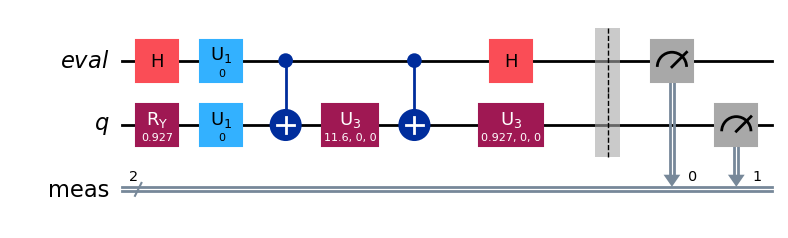

In [5]:
for c in circuits:
    print(f"Circuit : {c['identifier']}")
    print(f"Origin  : {c['origin']}")
    print(f"Qubits  : {c['n_qubits']}")
    print(f"Gates   : {len(c['qc'].data)}")
    display(c["qc"].draw("mpl", fold=-1))

---

## Visualisation Helper

We will draw each hypergraph as a **bipartite incidence diagram**:
- **Left column** — vertices (circles)
- **Right column** — hyperedges (squares)
- A line between a vertex and a hyperedge means *this vertex belongs to this hyperedge*

This makes it easy to see, at a glance, which objects are connected.

In [6]:
def draw_hypergraph(
    vertices,
    hyperedges,
    vertex_labels=None,
    edge_labels=None,
    vertex_color="#4C9BE8",
    edge_color="#F4845F",
    title=None,
    ax=None,
):
    """
    Visualise a hypergraph as a bipartite incidence diagram.

    Parameters
    ----------
    vertices   : list  — vertex identifiers (in display order)
    hyperedges : list of lists  — each inner list is a set of vertex identifiers
    vertex_labels : dict {vertex_id: label_string} or None
    edge_labels   : list of label strings (one per hyperedge) or None
    """
    n_v = len(vertices)
    n_e = len(hyperedges)

    if ax is None:
        height = max(4, max(n_v, n_e) * 0.55 + 1)
        fig, ax = plt.subplots(figsize=(7, height))

    # ── layout positions ──────────────────────────────────────────────────────
    v_y  = {v: (n_v - 1 - i) for i, v in enumerate(vertices)}
    e_y  = [(n_v - 1) * i / max(n_e - 1, 1) for i in range(n_e)]

    # ── incidence lines ───────────────────────────────────────────────────────
    for ei, edge in enumerate(hyperedges):
        for v in edge:
            if v in v_y:
                ax.plot(
                    [0.15, 0.85], [v_y[v], e_y[ei]],
                    color="#AAAAAA", lw=1.2, alpha=0.7, zorder=1,
                )

    # ── vertex nodes ─────────────────────────────────────────────────────────
    for v in vertices:
        y     = v_y[v]
        label = (vertex_labels or {}).get(v, str(v))
        ax.scatter(0.15, y, s=350, c=vertex_color, zorder=3, edgecolors="white", linewidths=1.5)
        ax.text(0.05, y, label, ha="right", va="center", fontsize=10, fontweight="bold")

    # ── hyperedge nodes ───────────────────────────────────────────────────────
    for ei, y in enumerate(e_y):
        label = (edge_labels[ei] if edge_labels else f"e{ei}")
        ax.scatter(0.85, y, s=350, c=edge_color, marker="s",
                   zorder=3, edgecolors="white", linewidths=1.5)
        ax.text(0.95, y, label, ha="left", va="center", fontsize=9)

    # ── column headers ────────────────────────────────────────────────────────
    ax.text(0.15, n_v + 0.3, "Vertices", ha="center", va="bottom",
            fontsize=10, color="#4C9BE8", fontweight="bold")
    ax.text(0.85, n_v + 0.3, "Hyperedges", ha="center", va="bottom",
            fontsize=10, color="#F4845F", fontweight="bold")

    if title:
        ax.set_title(title, fontsize=13, fontweight="bold", pad=12)

    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.8, n_v + 0.7)
    ax.axis("off")
    return ax

---

# 1. Telegate Representation

## What is it?

In the **Telegate** representation:

- Each **qubit** is a **vertex**.
- Each **multi-qubit gate** is a **hyperedge**, connecting all the qubits it acts on.

Single-qubit gates (rotations, Hadamard, etc.) involve only one qubit and can always
be executed locally, so they do not appear in the hypergraph.

## DQC interpretation

Partitioning a Telegate hypergraph means assigning qubits to QPUs.
A hyperedge is **cut** whenever its qubits end up on different QPUs.

Each cut edge corresponds to a gate that cannot be executed locally —
it must be implemented via a **non-local gate protocol**. The standard approach
uses gate teleportation: shared entanglement (an EPR pair) is consumed to "send"
the gate effect across QPUs without physically moving the qubit.
This is why the representation is called *Telegate*.

**Optimisation goal:** minimise the number of cut hyperedges
= minimise the number of teleported gates
= minimise entanglement consumption and classical communication.

In [7]:
def circuit_to_telegate(qc: QuantumCircuit):
    """
    Build the Telegate hypergraph from a Qiskit circuit.

    Returns
    -------
    vertices   : list[int]          — qubit indices  [0, 1, ..., n_qubits-1]
    hyperedges : list[list[int]]    — one per multi-qubit gate;
                                      each inner list holds the qubit indices
    gate_names : list[str]          — gate name for each hyperedge
    """
    qubit_index = {q: i for i, q in enumerate(qc.qubits)}
    vertices    = list(range(qc.num_qubits))
    hyperedges  = []
    gate_names  = []

    SKIP = {"barrier", "snapshot", "delay", "label", "measure"}

    for instruction in qc.data:
        op = instruction.operation
        if op.name in SKIP:
            continue
        if len(instruction.qubits) >= 2:
            # Deduplicate while preserving order
            edge = list(dict.fromkeys(qubit_index[q] for q in instruction.qubits))
            if len(edge) >= 2:
                hyperedges.append(edge)
                gate_names.append(op.name)

    return vertices, hyperedges, gate_names

Circuit : ae_indep_tket
Vertices (qubits)     : 2
Hyperedges (2q gates) : 2

Hyperedges:
  e00  cx          ['q0', 'q1']
  e01  cx          ['q0', 'q1']



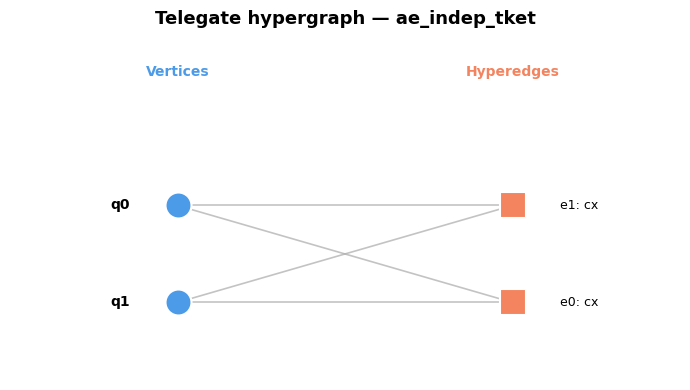

In [8]:
for c in circuits:
    qc = c["qc"]
    vertices, hyperedges, gate_names = circuit_to_telegate(qc)

    print(f"Circuit : {c['identifier']}")
    print(f"Vertices (qubits)     : {len(vertices)}")
    print(f"Hyperedges (2q gates) : {len(hyperedges)}")
    print()
    print("Hyperedges:")
    for i, (edge, name) in enumerate(zip(hyperedges, gate_names)):
        qubit_labels = [f"q{v}" for v in edge]
        print(f"  e{i:02d}  {name:10s}  {qubit_labels}")

    print()

    vertex_labels = {v: f"q{v}" for v in vertices}
    edge_labels   = [f"e{i}: {name}" for i, name in enumerate(gate_names)]

    draw_hypergraph(
        vertices, hyperedges,
        vertex_labels=vertex_labels,
        edge_labels=edge_labels,
        title=f"Telegate hypergraph — {c['identifier']}",
    )
    plt.tight_layout()
    plt.show()

In the diagram above, each **blue circle** is a qubit and each **orange square** is
a multi-qubit gate. A line between them means that qubit participates in that gate.

When you partition the qubits (blue circles) across QPUs, any gate (orange square)
whose qubits are on *different* QPUs becomes a non-local operation that requires
gate teleportation — consuming one EPR pair per teleported gate.

---

# 2. Teledata Representation

## What is it?

The **Teledata** representation is the *dual* of Telegate:

- Each **multi-qubit gate** is a **vertex**.
- Each **qubit wire** is a **hyperedge**, connecting all the gates that act on that qubit.

The hyperedge for qubit $q$ contains every gate that touches $q$, in the order
they appear in the circuit.

## DQC interpretation

Partitioning a Teledata hypergraph means assigning **gates** to QPUs
(deciding where each gate is executed).
A hyperedge is **cut** whenever consecutive gates on the same qubit are assigned
to different QPUs.

Each cut corresponds to a qubit's state needing to **travel** between QPUs —
accomplished by **quantum teleportation of the qubit state** itself (teledata).
This consumes one EPR pair and two classical bits per teleported qubit.

**Optimisation goal:** minimise the number of cut qubit wires
= minimise the number of state teleportations.

> **Telegate vs Teledata:** Both representations capture the same circuit from
> different angles. Telegate focuses on *where qubits live*; Teledata focuses on
> *where computation happens*. They can yield different partition solutions and
> different communication costs depending on the circuit structure.

In [9]:
def circuit_to_teledata(qc: QuantumCircuit):
    """
    Build the Teledata hypergraph from a Qiskit circuit.

    Returns
    -------
    vertices   : list[int]          — gate indices  [0, 1, ..., n_gates-1]
    hyperedges : list[list[int]]    — one per qubit;
                                      each inner list holds the gate indices
                                      that touch that qubit, in circuit order
    gate_names : list[str]          — name of each gate-vertex
    qubit_ids  : list[int]          — qubit index for each hyperedge
    """
    qubit_index = {q: i for i, q in enumerate(qc.qubits)}
    SKIP        = {"barrier", "snapshot", "delay", "label", "measure"}

    # Collect only multi-qubit gates (same gates as Telegate)
    multi_qubit_gates = []   # list of (gate_name, [qubit_indices])
    for instruction in qc.data:
        op = instruction.operation
        if op.name in SKIP:
            continue
        if len(instruction.qubits) >= 2:
            qubits = list(dict.fromkeys(qubit_index[q] for q in instruction.qubits))
            if len(qubits) >= 2:
                multi_qubit_gates.append((op.name, qubits))

    n_gates    = len(multi_qubit_gates)
    vertices   = list(range(n_gates))
    gate_names = [name for name, _ in multi_qubit_gates]

    # For each qubit, collect the gate indices that touch it
    qubit_to_gates = defaultdict(list)
    for gate_idx, (name, qubits) in enumerate(multi_qubit_gates):
        for q in qubits:
            qubit_to_gates[q].append(gate_idx)

    # Only keep qubits that appear in at least 2 gates (otherwise no cut is possible)
    qubit_ids  = sorted(qubit_to_gates.keys())
    hyperedges = [qubit_to_gates[q] for q in qubit_ids]

    return vertices, hyperedges, gate_names, qubit_ids

Circuit : ae_indep_tket
Vertices (2q gates)  : 2
Hyperedges (qubits)  : 2

Hyperedges:
  q0  ['g0(cx)', 'g1(cx)']
  q1  ['g0(cx)', 'g1(cx)']



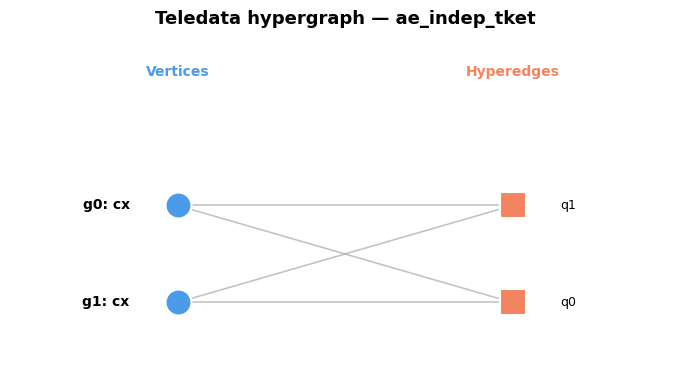

In [10]:
for c in circuits:
    qc = c["qc"]
    vertices, hyperedges, gate_names, qubit_ids = circuit_to_teledata(qc)

    print(f"Circuit : {c['identifier']}")
    print(f"Vertices (2q gates)  : {len(vertices)}")
    print(f"Hyperedges (qubits)  : {len(hyperedges)}")
    print()
    print("Hyperedges:")
    for q_idx, edge in zip(qubit_ids, hyperedges):
        gate_labels = [f"g{g}({gate_names[g]})" for g in edge]
        print(f"  q{q_idx}  {gate_labels}")

    print()

    vertex_labels = {v: f"g{v}: {gate_names[v]}" for v in vertices}
    edge_labels   = [f"q{q}" for q in qubit_ids]

    draw_hypergraph(
        vertices, hyperedges,
        vertex_labels=vertex_labels,
        edge_labels=edge_labels,
        title=f"Teledata hypergraph — {c['identifier']}",
    )
    plt.tight_layout()
    plt.show()

In the diagram above, each **blue circle** is a gate and each **orange square** is
a qubit wire. A line between them means that gate acts on that qubit.

When you partition the gates (blue circles) across QPUs, any qubit wire (orange square)
that connects gates on *different* QPUs requires the qubit state to be teleported
— consuming one EPR pair per teleportation.

---

# 3. HDH Representation

## What is it?

The **HDH (Hypergraph Data-flow Hypergraph)** is a finer-grained representation
that tracks the *state* of each qubit through time:

- A **vertex** is introduced for each transformation a qubit state undergoes —
  so qubit $q$ at timestep $t$ becomes a node labelled `q_t`.
- Each **gate** is a **hyperedge**, connecting the input qubit-states to the
  output qubit-states it transforms.

This is a **directed typed hypergraph** — edges have direction (input → output)
and both vertices and edges carry type metadata.

## Metadata and types

HDH distinguishes **quantum** and **classical** objects:

| Symbol | Meaning |
|---|---|
| `sigma[node] = 'q'` | quantum qubit node |
| `sigma[node] = 'c'` | classical bit node |
| `tau[edge]   = 'q'` | quantum gate (cutting is expensive) |
| `tau[edge]   = 'c'` | classical gate (cutting is cheap or free) |

This distinction matters because cutting through a *quantum* operation requires
quantum communication (EPR pairs), while cutting through a *classical* operation
only needs classical communication.

The HDH also retains enough information to **reconstruct the original circuit**
from the hypergraph — something neither Telegate nor Teledata can do on their own.

## DQC interpretation

HDH is the most expressive of the three representations:
- It captures the temporal ordering of operations.
- It differentiates classical from quantum communication costs.
- It enables analysis of data-flow dependencies that Telegate and Teledata abstract away.

Partitioning an HDH gives a partition that is aware of *both* quantum and classical
overheads, leading to more accurate cost estimates for real DQC architectures.

In [11]:
# All packages were installed in the Setup cell at the top of the notebook.
# If you skipped it, run:  %pip install qiskit[visualization] matplotlib hdh


In [12]:
from hdh.converters import from_qiskit
from hdh.visualize import plot_hdh

In [13]:
def circuit_to_hdh(qc: QuantumCircuit):
    """
    Build the HDH representation from a Qiskit circuit using the hdh library.

    Returns the HDH object, which exposes:
      .S          — set of node identifiers  (e.g. 'q0_t0', 'c1_t2')
      .C          — set of hyperedges        (frozensets of node ids)
      .sigma      — dict: node_id -> type ('q' quantum | 'c' classical)
      .tau        — dict: edge    -> type ('q' quantum | 'c' classical)
      .time_map   — dict: node_id -> timestep (int)
      .gate_name  — dict: edge    -> gate name string
      .upsilon    — dict: edge    -> realization ('a' actual | 'p' predicted)
    """
    return from_qiskit(qc)

In [14]:
for c in circuits:
    qc  = c["qc"]
    hdh = circuit_to_hdh(qc)

    print(f"Circuit : {c['identifier']}")
    print(f"Nodes (qubit-state moments) : {len(hdh.S)}")
    print(f"Hyperedges (gates)          : {len(hdh.C)}")
    print()

    # ── Inspect node types ────────────────────────────────────────────────────
    quantum_nodes   = [n for n in hdh.S if hdh.sigma[n] == 'q']
    classical_nodes = [n for n in hdh.S if hdh.sigma[n] == 'c']
    print(f"Quantum nodes   : {len(quantum_nodes)}")
    print(f"Classical nodes : {len(classical_nodes)}")
    print()

    # ── Inspect edge types ────────────────────────────────────────────────────
    quantum_edges   = [e for e in hdh.C if hdh.tau[e] == 'q']
    classical_edges = [e for e in hdh.C if hdh.tau[e] == 'c']
    print(f"Quantum edges   : {len(quantum_edges)}  ← cutting these is expensive (EPR pairs)")
    print(f"Classical edges : {len(classical_edges)}  ← cutting these only needs classical comms")
    print()

    # ── Sample nodes and edges ────────────────────────────────────────────────
    print("Sample nodes (up to 8):")
    for n in sorted(hdh.S)[:8]:
        t    = hdh.time_map[n]
        kind = "quantum" if hdh.sigma[n] == 'q' else "classical"
        print(f"  {n:12s}  t={t}  type={kind}")

    print()
    print("Sample edges (up to 5):")
    for e in list(hdh.C)[:5]:
        name   = hdh.gate_name[e]
        kind   = "quantum" if hdh.tau[e] == 'q' else "classical"
        nodes  = sorted(e)
        print(f"  gate={name:10s}  type={kind:9s}  nodes={nodes}")

Circuit : ae_indep_tket
Nodes (qubit-state moments) : 23
Hyperedges (gates)          : 19

Quantum nodes   : 21
Classical nodes : 2

Quantum edges   : 17  ← cutting these is expensive (EPR pairs)
Classical edges : 2  ← cutting these only needs classical comms

Sample nodes (up to 8):
  c0_t11        t=11  type=classical
  c1_t11        t=11  type=classical
  q0_t0         t=0  type=quantum
  q0_t1         t=1  type=quantum
  q0_t10        t=10  type=quantum
  q0_t2         t=2  type=quantum
  q0_t3         t=3  type=quantum
  q0_t4         t=4  type=quantum

Sample edges (up to 5):
  gate=cx_stage1   type=quantum    nodes=['q1_t6', 'q1_t7']
  gate=measure     type=classical  nodes=['c1_t11', 'q1_t10']
  gate=cx_stage3   type=quantum    nodes=['q0_t4', 'q0_t5']
  gate=u1          type=quantum    nodes=['q1_t1', 'q1_t2']
  gate=u3          type=quantum    nodes=['q1_t10', 'q1_t9']


HDH visualisation — ae_indep_tket
Plot saved to: hdh_plot.svg


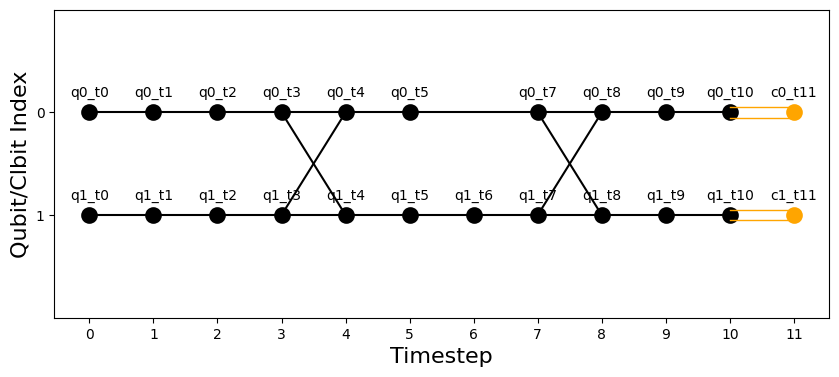

In [15]:
# ── Visualise the HDH ─────────────────────────────────────────────────────────
# The HDH library renders the graph directly.
# Black nodes = quantum;  orange nodes = classical.
# Filled circles = actual (past) operations;  hollow = predicted (future).

for c in circuits:
    hdh = circuit_to_hdh(c["qc"])
    print(f"HDH visualisation — {c['identifier']}")
    plot_hdh(hdh)

---

## Summary

The three representations trade off **granularity** against **complexity**:

| Representation | Strengths | Typical use |
|---|---|---|
| **Telegate** | Simple, well-studied, fast to partition | When qubit placement drives cost; optimise non-local gate count |
| **Teledata** | Captures data-flow between gates | When qubit movement dominates; optimise teleportation count |
| **HDH** | Preserves full circuit semantics, classical/quantum distinction, reconstructable | When accurate cost modelling matters or when comparing mixed quantum/classical circuits |

In practice, Telegate and Teledata produce the same cut cost for circuits where
each qubit is used by the same number of gates, but diverge for asymmetric circuits.
HDH is the most expressive but also the most computationally demanding to partition.